# TP03 - CLASIFICANDO DE POBRES CON LA EPH – [Taller de Programación]
## Alumnos:  Kostzer Federico - Meza Palma Manuel Humberto - Pardini Maximiliano Gabriel - 
## Fecha: 15/11/2025

A. Enfoque de validación 

Utilicen la base respondieron. Para cada año, dividan las observaciones en una base de prueba (test) y una de entrenamiento (train) utilizando el comando train_test_split. La base de entrenamiento debe comprender el 70% de los datos, y la semilla a utilizar (random state instance) debe ser 444. Establezca a pobre como su variable dependiente en la base de entrenamiento (vector y). El resto de las variables seleccionadas serán las variables independientes (matriz X). Recuerden agregar la columna de unos (1) para el intercepto. Aclaración: no incluir la variable ingreso en X para predecir la pobreza porque cuando vayamos a la base de norespondieron no vamos a tener esa información. 


1.	 Cree una tabla de diferencia de medias entre la base de entrenamiento y la de testeo de las características seleccionadas en su matriz X. Para la matriz de las X seleccione variables que hayan limpiado en los TPs anteriores y justifique su inclusión para predecir la pobreza. Comente la tabla de la diferencia de medias de sus variables entre entrenamiento y testeo. ¿Hay diferencias significativas entre las medias del entrenamiento y testeo? 

In [30]:
# %% ------------------------------------
# 📦 Configuración inicial
# %% ------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
import seaborn as sns
import numpy as np
from pathlib import Path
import os
print(os.getcwd())
import statsmodels.api as sm  
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, recall_score 
from sklearn.metrics import RocCurveDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score




sns.set(style="whitegrid")

C:\Users\Machi Pardini\Documents\GitHub\Big-Data-UBA--Grupo-3\TP03


In [31]:
## Configuracion de ruta y base de datos

# Detectar automáticamente la raíz del repositorio (carpeta que contiene .git)
# Si tu notebook está dentro de una o más subcarpetas, este código igual funcionará
RUTA_REPO = Path.cwd()
while not (RUTA_REPO / ".git").exists() and RUTA_REPO != RUTA_REPO.parent:
    RUTA_REPO = RUTA_REPO.parent

# Definir la ruta base (por ejemplo, carpeta BASES dentro del repo)
RUTA_BASE = RUTA_REPO / "TP03"

print(f"📁 Raíz del repositorio: {RUTA_REPO}")
print(f"📂 Carpeta de bases: {RUTA_BASE}")
 

📁 Raíz del repositorio: C:\Users\Machi Pardini\Documents\GitHub\Big-Data-UBA--Grupo-3
📂 Carpeta de bases: C:\Users\Machi Pardini\Documents\GitHub\Big-Data-UBA--Grupo-3\TP03


In [32]:
RUTA_BASE = Path.cwd()   # la carpeta actual

print("RUTA_BASE:", RUTA_BASE)

# ==============================
#  Cargar base respondieron
# ==============================
respondieron_ruta = RUTA_BASE / "respondieron.csv"
respondieron = pd.read_csv(respondieron_ruta, encoding="utf-8", low_memory=False)
respondieron.columns = respondieron.columns.str.strip()


RUTA_BASE: C:\Users\Machi Pardini\Documents\GitHub\Big-Data-UBA--Grupo-3\TP03


In [33]:
# ==============================
#  Cargar base respondieron
# ==============================
respondieron_ruta = os.path.join(RUTA_BASE, "respondieron.csv")
respondieron = pd.read_csv(respondieron_ruta, encoding="utf-8", low_memory=False)
respondieron.columns = respondieron.columns.str.strip()  # limpiar espacios

In [34]:
ruta_norespondieron = RUTA_BASE / "norespondieron.csv"
norespondieron = pd.read_csv(ruta_norespondieron, low_memory=False)
norespondieron.columns = norespondieron.columns.str.strip()


In [35]:
# ==============================
#  Limpiar pp3e_tot
# ==============================

# Revisar las primeras filas
print(respondieron.head())

# ============================
# 2. Calcular percentil 99
# ============================
q99 = respondieron["pp3e_tot"].quantile(0.99)
print(f"Percentil 99: {q99:.1f} horas")

# ============================
# 3. Reemplazar valores mayores al percentil 99 por NaN
# ============================
respondieron["pp3e_tot_clean"] =respondieron["pp3e_tot"].where(respondieron["pp3e_tot"] <= q99)

# ============================
# 4. Resumen de la variable limpia
# ============================
print(respondieron["pp3e_tot_clean"].describe())
print("Valores únicos después de filtrar el percentil 99:", 
      np.sort(respondieron["pp3e_tot_clean"].dropna().unique()))




     codusu  nro_hogar componente  h15    ano4       trimestre  region  \
0  125098          1.0        1.0   Sí  2005.0  1er. Trimestre       1   
1  125188          1.0        1.0   Sí  2005.0  1er. Trimestre       1   
2  125188          1.0        2.0   Sí  2005.0  1er. Trimestre       1   
3  125188          1.0        3.0  0.0  2005.0  1er. Trimestre       1   
4  125242          1.0        1.0   Sí  2005.0  1er. Trimestre       1   

  mas_500  aglomerado  pondera  ...    anio   sexo  sexo_texto  edad_str  \
0       S         NaN   1017.0  ...  2005.0  Varón     varones    80años   
1       S         NaN   1062.0  ...  2005.0  Varón     varones    26años   
2       S         NaN   1062.0  ...  2005.0  Mujer     mujeres    27años   
3       S         NaN   1062.0  ...  2005.0  Mujer     mujeres     other   
4       S         NaN   1103.0  ...  2005.0  Mujer     mujeres    71años   

   ad_equiv_hogar  edad  adulto_equiv  cbt_ae ingreso_necesario pobre  
0             1.0   NaN   

In [36]:


# ==============================
#  Variables seleccionadas
# ==============================
vars_pred = ['ch04','ch06','ch07','pp3e_tot_clean','nivel_ed','estado','ch03','ch09','ch10']

# ==============================
#  Crear DataFrame de modelo
# ==============================
df_modelo = respondieron[vars_pred + ['pobre']].copy()

# ==============================
# 4️⃣ Imputar NAs con mediana para numéricas
# ==============================
num_cols = ['ch06','ch07','pp3e_tot_clean','estado','ch09','ch10', ]  # columnas numéricas
for col in num_cols:
    med = df_modelo[col].median()
    df_modelo[col] = df_modelo[col].fillna(med)

# ==============================
# 5️⃣ Convertir categóricas a dummies
# ==============================
cat_cols = ['ch04','nivel_ed']  # columnas categóricas
df_modelo = pd.get_dummies(df_modelo, columns=cat_cols, drop_first=True)

# ==============================
# 6️⃣ Separar X e y
# ==============================
X = df_modelo.drop(columns='pobre')
y = df_modelo['pobre']

# ==============================
# 7️⃣ Agregar columna de unos (intercepto)
# ==============================
X = X.assign(intercepto=1)

# ==============================
# 8️⃣ Dividir en train y test (70/30)
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=444
)

# ==============================
# 9️⃣ Diferencia de medias (opcional)
# ==============================
mean_train = X_train.mean()
mean_test  = X_test.mean()

diff_means = pd.DataFrame({
    'Media_Train': mean_train,
    'Media_Test': mean_test,
    'Dif_Media': mean_train - mean_test
})
diff_means['Abs_Dif'] = diff_means['Dif_Media'].abs()
diff_means_sorted = diff_means.sort_values(by='Abs_Dif', ascending=False)

print("📊 Diferencia de medias entre Train y Test:")
display(diff_means_sorted.head(20))


📊 Diferencia de medias entre Train y Test:


,Media_Train,Media_Test,Dif_Media,Abs_Dif
pp3e_tot_clean,13.954997,13.695665,0.259332,0.259332
ch06,34.123825,33.961401,0.162425,0.162425
estado,2.295923,2.311088,-0.015165,0.015165
ch04_2,0.519634,0.526511,-0.006877,0.006877
ch10,1.719834,1.713172,0.006662,0.006662
ch07,3.574731,3.580117,-0.005386,0.005386
nivel_ed_3,0.190964,0.193997,-0.003034,0.003034
nivel_ed_6,0.108157,0.105169,0.002989,0.002989
ch03,2.511184,2.508295,0.002889,0.002889
nivel_ed_4,0.171598,0.168862,0.002736,0.002736


In [37]:
na_counts = respondieron[vars_pred + ['pobre']].isna().sum()
print(na_counts)


ch04                  0
ch06                935
ch07                  5
pp3e_tot_clean    19450
nivel_ed              0
estado               58
ch03                  0
ch09                  6
ch10               1954
pobre                 0
dtype: int64


2. Separen la base respondieron en dos: respondieron_2005 y respondieron_2025. Idem con la base norespondieron.

In [38]:
# ==============================
# Separar por año
# ==============================
respondieron_2005 = respondieron[respondieron['ano4'] == 2005].copy()
respondieron_2025 = respondieron[respondieron['ano4'] == 2025].copy()

# Verificar cantidad de filas por año
print("Cantidad de registros 2005:", len(respondieron_2005))
print("Cantidad de registros 2025:", len(respondieron_2025))


Cantidad de registros 2005: 46592
Cantidad de registros 2025: 33372


In [39]:

# Limpiar espacios en nombres de columnas
norespondieron.columns = norespondieron.columns.str.strip()

# Verificar primer vistazo
print(norespondieron.head())
print(f"Cantidad total de registros: {len(norespondieron)}")

norespondieron_2005 = norespondieron[norespondieron['ano4']==2005].copy()
norespondieron_2025 = norespondieron[norespondieron['ano4']==2025].copy()

print(f"Cantidad de registros 2005: {len(norespondieron_2005)}")
print(f"Cantidad de registros 2025: {len(norespondieron_2025)}")



     codusu  nro_hogar componente  h15    ano4       trimestre  region  \
0  155508          1.0        1.0   Sí  2005.0  1er. Trimestre       1   
1  155508          1.0        2.0   Sí  2005.0  1er. Trimestre       1   
2  155508          1.0        3.0   Sí  2005.0  1er. Trimestre       1   
3  155508          1.0        4.0  0.0  2005.0  1er. Trimestre       1   
4  160429          1.0        1.0   Sí  2005.0  1er. Trimestre       1   

  mas_500  aglomerado  pondera  ...  v22_02_m  v22_03_m  p_deccf  p_rdeccf  \
0       S         NaN   1401.0  ...       NaN       NaN      NaN       NaN   
1       S         NaN   1401.0  ...       NaN       NaN      NaN       NaN   
2       S         NaN   1401.0  ...       NaN       NaN      NaN       NaN   
3       S         NaN   1401.0  ...       NaN       NaN      NaN       NaN   
4       S         NaN   1202.0  ...       NaN       NaN      NaN       NaN   

   p_gdeccf  p_pdeccf  p_ideccf p_adeccf    anio   sexo  
0       NaN       NaN       

# ==============================
# 1️⃣ Cargar base norespondieron
# ==============================
ruta_norespondieron = r"..\TP01\norespondieron.csv"
norespondieron = pd.read_csv(ruta_norespondieron, low_memory=False)

# Limpiar espacios en nombres de columnas
norespondieron.columns = norespondieron.columns.str.strip()

# Verificar primer vistazo
print(norespondieron.head())
print(f"Cantidad total de registros: {len(norespondieron)}")

norespondieron_2005 = norespondieron[norespondieron['ano4']==2005].copy()
norespondieron_2025 = norespondieron[norespondieron['ano4']==2025].copy()

print(f"Cantidad de registros 2005: {len(norespondieron_2005)}")
print(f"Cantidad de registros 2025: {len(norespondieron_2025)}")



In [40]:
# ==============================
# 1️⃣ Cargar base norespondieron
# ==============================
ruta_norespondieron = r"..\TP01\norespondieron.csv"
norespondieron = pd.read_csv(ruta_norespondieron, low_memory=False)

# Limpiar espacios en nombres de columnas
norespondieron.columns = norespondieron.columns.str.strip()

# Verificar primer vistazo
print(norespondieron.head())
print(f"Cantidad total de registros: {len(norespondieron)}")

norespondieron_2005 = norespondieron[norespondieron['ano4']==2005].copy()
norespondieron_2025 = norespondieron[norespondieron['ano4']==2025].copy()

print(f"Cantidad de registros 2005: {len(norespondieron_2005)}")
print(f"Cantidad de registros 2025: {len(norespondieron_2025)}")



     codusu  nro_hogar componente  h15    ano4       trimestre  region  \
0  155508          1.0        1.0   Sí  2005.0  1er. Trimestre       1   
1  155508          1.0        2.0   Sí  2005.0  1er. Trimestre       1   
2  155508          1.0        3.0   Sí  2005.0  1er. Trimestre       1   
3  155508          1.0        4.0  0.0  2005.0  1er. Trimestre       1   
4  160429          1.0        1.0   Sí  2005.0  1er. Trimestre       1   

  mas_500  aglomerado  pondera  ...  v22_02_m  v22_03_m  p_deccf  p_rdeccf  \
0       S         NaN   1401.0  ...       NaN       NaN      NaN       NaN   
1       S         NaN   1401.0  ...       NaN       NaN      NaN       NaN   
2       S         NaN   1401.0  ...       NaN       NaN      NaN       NaN   
3       S         NaN   1401.0  ...       NaN       NaN      NaN       NaN   
4       S         NaN   1202.0  ...       NaN       NaN      NaN       NaN   

   p_gdeccf  p_pdeccf  p_ideccf p_adeccf    anio   sexo  
0       NaN       NaN       

B. Modelo de Regresion Logística 

3.	Estimación y Efectos Marginales: Estimen una Regresión Logística usando X_train de respondieron_2025. Exporten una tabla con: (i) los coeficientes estimados para cada variable, (ii) los errores estándar y (ii) los odd-ratios. Interpreten los resultados de la tabla. (Hint: en la clase 7 hay una ilustración de la tabla).

In [41]:
# ==========================================================
# B. MODELO DE REGRESIÓN LOGÍSTICA (AÑO 2025)
# ==========================================================

# ----------------------------------------------------------
# 1️⃣ Definir variables predictoras y dependiente
# ----------------------------------------------------------
variables_X = ['ch04', 'ch06', 'ch07', 'pp3e_tot_clean', 'nivel_ed', 'estado', 'ch03', 'ch09', 'ch10']
y = respondieron_2025['pobre']
X = respondieron_2025[variables_X]

# ----------------------------------------------------------
# 2️⃣ Imputar valores faltantes con la mediana de cada variable
# ----------------------------------------------------------
X = X.fillna(X.median())

# ----------------------------------------------------------
# 3️⃣ Dividir en entrenamiento (70%) y prueba (30%)
# ----------------------------------------------------------
X_train_2025, X_test_2025, y_train_2025, y_test_2025 = train_test_split(
    X, y, test_size=0.3, random_state=444
)

# ----------------------------------------------------------
# 4️⃣ Agregar columna de unos para el intercepto
# ----------------------------------------------------------
X_train_2025 = sm.add_constant(X_train_2025)
X_test_2025 = sm.add_constant(X_test_2025)

# ----------------------------------------------------------
# 5️⃣ Estimar el modelo Logit
# ----------------------------------------------------------
logit_model = sm.Logit(y_train_2025, X_train_2025)
result = logit_model.fit(disp=1)

# ----------------------------------------------------------
# 6️⃣ Crear tabla de resultados
# ----------------------------------------------------------
tabla_resultados = pd.DataFrame({
    'Coeficiente': result.params,
    'Error_Estándar': result.bse,
    'z': result.tvalues,
    'p-valor': result.pvalues,
    'Odds_Ratio': np.exp(result.params)
}).round(4)

# ----------------------------------------------------------
# 7️⃣ Mostrar resultados
# ----------------------------------------------------------
print(result.summary())
print("\nTabla resumen de coeficientes, errores estándar y odds ratios:\n")
print(tabla_resultados)


Optimization terminated successfully.
         Current function value: 0.634603
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                  pobre   No. Observations:                23360
Model:                          Logit   Df Residuals:                    23350
Method:                           MLE   Df Model:                            9
Date:                Fri, 14 Nov 2025   Pseudo R-squ.:                 0.08063
Time:                        22:32:02   Log-Likelihood:                -14824.
converged:                       True   LL-Null:                       -16124.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0690      0.111      0.619      0.536      -0.149       0.287
ch04             

4. Visualización: Grafiquen la P ̂(Y=1|X) (en el eje vertical) y alguna característica numérica (en el eje horizontal). Comente dicho gráfico y la variable seleccionada para ilustrar la probabilidad de ser pobre según la característica seleccionada. (Hint: en la clase 7 hay una ilustración de este estilo).

📊 Estadísticas descriptivas de edad:
count    23360.000000
mean        36.582748
std         22.084683
min          1.000000
25%         18.000000
50%         34.000000
75%         53.000000
max        103.000000
Name: ch06, dtype: float64

📈 Distribución de edad:
ch06
1.0      187
2.0      210
3.0      249
4.0      265
5.0      324
        ... 
96.0       5
97.0       1
98.0       2
99.0       1
103.0      1
Name: count, Length: 100, dtype: int64

📉 Probabilidad promedio de pobreza por edad:
   edad  prob_pobre
0   1.0    0.681814
1   2.0    0.687463
2   3.0    0.605072
3   4.0    0.491253
4   5.0    0.564412
5   6.0    0.763754
6   7.0    0.782403
7   8.0    0.776012
8   9.0    0.772169
9  10.0    0.726931


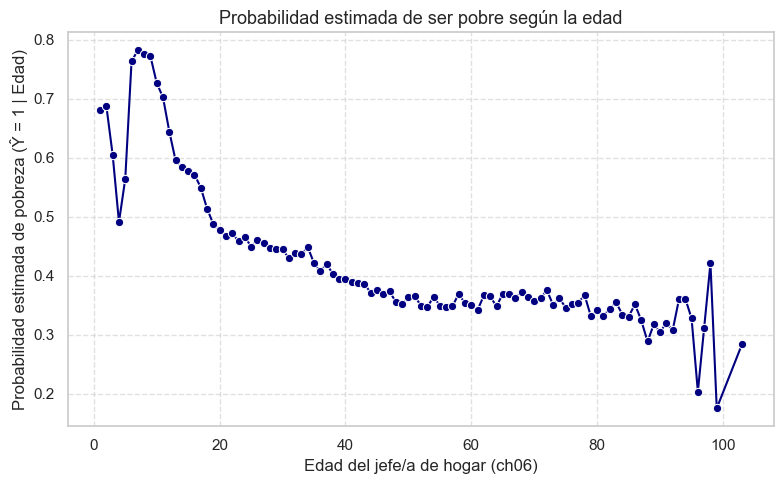

In [42]:
# ==========================================================
# ANÁLISIS DESCRIPTIVO DE LA VARIABLE EDAD Y SU RELACIÓN CON LA POBREZA
# ==========================================================

# 1️⃣ Estadísticas descriptivas básicas de edad
print("📊 Estadísticas descriptivas de edad:")
print(X_train_2025['ch06'].describe())

# 2️⃣ Distribución de frecuencia de edad
print("\n📈 Distribución de edad:")
print(X_train_2025['ch06'].value_counts().sort_index())

# ----------------------------------------------------------
# 3️⃣ Alineamos columnas con las del modelo original
# ----------------------------------------------------------
# Usamos solo las columnas que el modelo efectivamente utilizó
X_train_pred = X_train_2025[result.model.exog_names]

# ----------------------------------------------------------
# 4️⃣ Predecimos las probabilidades
# ----------------------------------------------------------
pred_probs = result.predict(X_train_pred)

# 5️⃣ Creamos un DataFrame con edad y probabilidad
df_plot = pd.DataFrame({
    'edad': X_train_2025['ch06'],
    'prob_pobre': pred_probs
})

# 6️⃣ Calculamos la probabilidad promedio de ser pobre por edad
edad_prob = df_plot.groupby('edad', as_index=False)['prob_pobre'].mean()

print("\n📉 Probabilidad promedio de pobreza por edad:")
print(edad_prob.head(10))

# 7️⃣ Graficamos la relación edad - probabilidad de pobreza
plt.figure(figsize=(8,5))
sns.lineplot(data=edad_prob, x='edad', y='prob_pobre', marker='o', color='navy')
plt.title("Probabilidad estimada de ser pobre según la edad", fontsize=13)
plt.xlabel("Edad del jefe/a de hogar (ch06)")
plt.ylabel("Probabilidad estimada de pobreza (Ŷ = 1 | Edad)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [14]:
# Contar cuántos casos hay para cada edad
conteo_edad = X_train_2025['ch06'].value_counts().sort_index()
print(conteo_edad.tail(10))  # ver las edades más altas


91.0     11
92.0      9
93.0      8
94.0      4
95.0      8
96.0      5
97.0      1
98.0      2
99.0      1
103.0     1
Name: ch06, dtype: int64


## C. Método de Vecinos Cercanos (KNN)

5.	Estimación: Clasifiquen a las observaciones como “pobre”/“no pobre” en su región con Vecinos Cercanos (KNN) usando  K={1,5,10} para su matriz X_train de respondieron_2025. Expliquen en no más de 2-3 oraciones cómo la elección de K se relaciona con el trade-off sesgo varianza.  

In [43]:
# Veamos la dimension de los vectores creados
print(X_train_2025.shape, X_test_2025.shape, y_train_2025.shape, y_test_2025.shape)

X_train_2025



(23360, 10) (10012, 10) (23360,) (10012,)


,const,ch04,ch06,ch07,pp3e_tot_clean,nivel_ed,estado,ch03,ch09,ch10
60330,1.0,1,28.0,1.0,36.0,3,3.0,3,1.0,2.0
57751,1.0,2,25.0,5.0,45.0,4,1.0,1,1.0,2.0
50846,1.0,1,8.0,5.0,36.0,1,4.0,3,1.0,1.0
75259,1.0,1,34.0,1.0,24.0,3,1.0,1,1.0,2.0
71640,1.0,1,7.0,5.0,36.0,1,4.0,9,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...
52207,1.0,1,33.0,5.0,66.0,5,1.0,3,1.0,2.0
51382,1.0,2,46.0,2.0,60.0,4,1.0,2,1.0,2.0
53223,1.0,2,16.0,5.0,36.0,3,3.0,3,1.0,1.0
71959,1.0,2,62.0,2.0,36.0,4,3.0,1,1.0,2.0


In [44]:
y_train_2025

60330    1
57751    0
50846    1
75259    1
71640    1
        ..
52207    0
51382    0
53223    1
71959    0
70531    0
Name: pobre, Length: 23360, dtype: int64

In [45]:
# Eliminamos la columna del intercepto de los conjuntos de predictores

X_train_knn = X_train_2025.drop(columns=['const'])
X_test_knn = X_test_2025.drop(columns=['const'])

# Entrenamos el modelo

for k in [1, 5, 10]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_knn, y_train_2025)
    y_pred = knn.predict(X_test_knn)
    print(f"K={k} → Accuracy: {accuracy_score(y_test_2025, y_pred):.3f}")


K=1 → Accuracy: 0.594
K=5 → Accuracy: 0.626
K=10 → Accuracy: 0.640


In [46]:
# Tomando el numero de vecinos optimo k=10 para reentrenar el modelo

knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train_knn, y_train_2025)

# Obteniendo las nuevas metricas

y_test_pred_knn = knn.predict(X_test_knn)
accuracy_knn = accuracy_score(y_test_2025, y_test_pred_knn)
print("La exactitud del modelo es: %.3f" %accuracy_knn)  

# Matriz de confusion
print(pd.crosstab(index=y_test_2025, columns=y_test_pred_knn))



La exactitud del modelo es: 0.640
col_0     0     1
pobre            
0      3922  1543
1      2059  2488


6.	Visualización: Grafiquen dos características numéricas de su matriz X_train y visualicen las clases predichas por KNN usando con K=(1,10) con su frontera por clase “pobre”/“no pobre”.

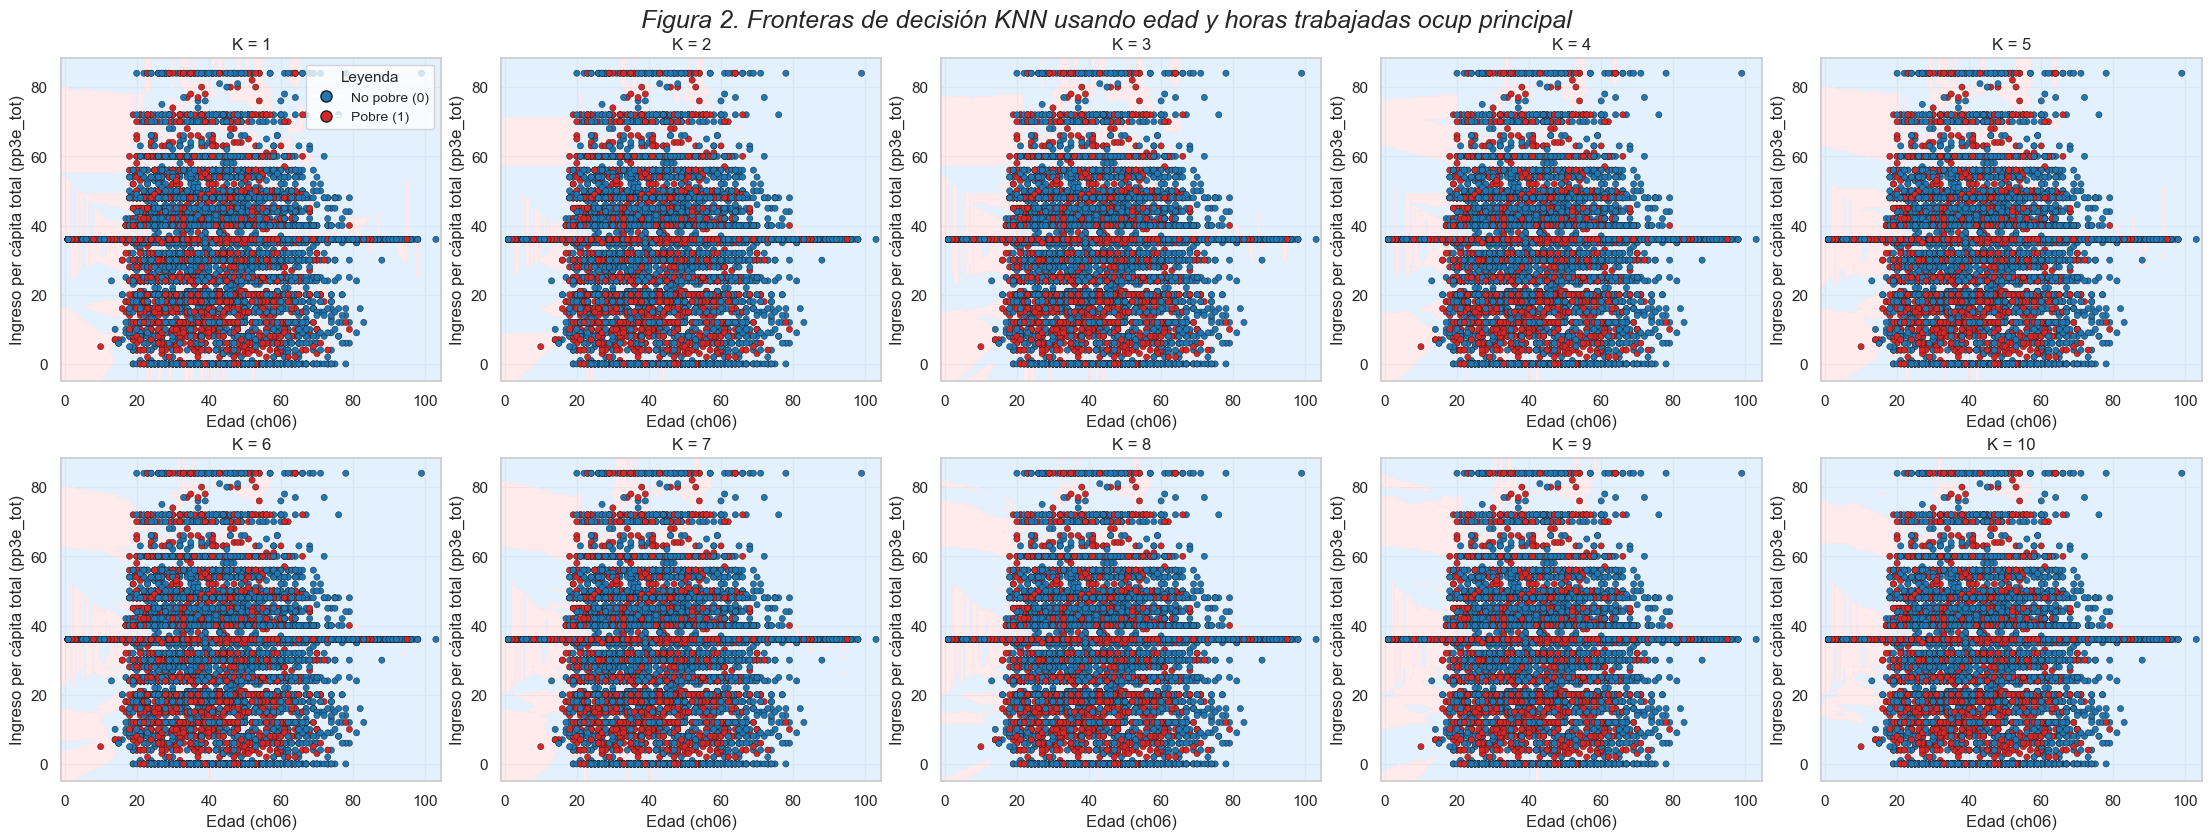

In [47]:

# ============================
# 1. Preparación de X e y
# ============================

# Quitar constante si está presente
X_knn = X_train_knn.drop(columns=["const"], errors="ignore")

# Variables numéricas a graficar
X_arr = X_knn[["ch06", "pp3e_tot_clean"]].values  
y_arr = y_train_2025.values

# ============================
# 2. Malla para frontera
# ============================
h = 0.5  

x_min, x_max = X_arr[:, 0].min() - 2, X_arr[:, 0].max() + 2
y_min, y_max = X_arr[:, 1].min() - 5, X_arr[:, 1].max() + 5

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

# ============================
# 3. Gráficos para K = 1 a 10
# ============================
Ks = range(1, 11)

fig, axes = plt.subplots(2, 5, figsize=(22, 8), constrained_layout=True)

# Título general
fig.suptitle(
    "Figura 2. Fronteras de decisión KNN usando edad y horas trabajadas ocup principal",
    fontsize=18, fontstyle='italic', y=1.03
)

# Colores
cmap_bg = ListedColormap(["#ddeeff", "#ffe6e6"])  # Fondos
cmap_pts = ListedColormap(["#1f77b4", "#d62728"]) # Puntos

axes = axes.ravel()

# ============================
# 4. Leyenda específica
# ============================
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='No pobre (0)',
           markerfacecolor='#1f77b4', markersize=8, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w', label='Pobre (1)',
           markerfacecolor='#d62728', markersize=8, markeredgecolor='k')
]

for ax, K in zip(axes, Ks):

    # Entrenar modelo
    knn = KNeighborsClassifier(n_neighbors=K)
    knn.fit(X_arr, y_arr)

    # Predecir en la malla
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Fronteras
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=cmap_bg, levels=[-0.5, 0.5, 1.5])

    # Puntos reales
    scatter = ax.scatter(
        X_arr[:, 0], X_arr[:, 1],
        c=y_arr, cmap=cmap_pts,
        s=20, edgecolor="k", linewidth=0.3,
        label=None
    )

    ax.set_title(f"K = {K}")
    ax.set_xlabel("Edad (ch06)")
    ax.set_ylabel("Ingreso per cápita total (pp3e_tot)")

    # Leyenda solo en el primer subplot
    if K == 1:
        ax.legend(
            handles=legend_elements,
            loc='upper right',
            fontsize=10,
            frameon=True,
            title="Leyenda",
            title_fontsize=11
        )

plt.show()


In [20]:
X_knn.describe()

,ch04,ch06,ch07,pp3e_tot_clean,nivel_ed,estado,ch03,ch09,ch10
count,23360.000000,23360.000000,23360.000000,23360.000000,23360.000000,23360.000000,23360.000000,23360.000000,23360.000000
mean,1.522089,36.582748,3.538656,34.861173,3.733219,2.242979,2.404067,1.082877,1.711729
std,0.499523,22.084683,1.647614,11.538830,1.751864,1.127188,1.564091,0.323829,0.494967
min,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,18.000000,2.000000,36.000000,2.000000,1.000000,1.000000,1.000000,1.000000
50%,2.000000,34.000000,5.000000,36.000000,4.000000,3.000000,2.000000,1.000000,2.000000
75%,2.000000,53.000000,5.000000,36.000000,5.000000,3.000000,3.000000,1.000000,2.000000
max,2.000000,103.000000,5.000000,84.000000,7.000000,4.000000,10.000000,3.000000,9.000000


In [21]:
# Valores únicos
valores_unicos = X_knn["pp3e_tot_clean"].unique()
print(valores_unicos)


[36. 45. 24.  4.  0. 56. 49. 84. 40. 20. 32. 25. 16. 21. 15.  6. 48. 30.
 12. 35. 18. 53. 72. 54. 60. 42. 44.  7.  3. 14. 47. 70. 22. 23. 10.  8.
  5. 28. 65. 50. 55. 38. 63. 77. 13. 52. 46. 19. 27. 34. 43.  9. 74. 64.
 26. 41. 33. 29.  2. 58. 17. 31. 59. 57. 37. 66.  1. 81. 61. 11. 51. 76.
 68. 78. 80. 39. 62. 82. 75.]


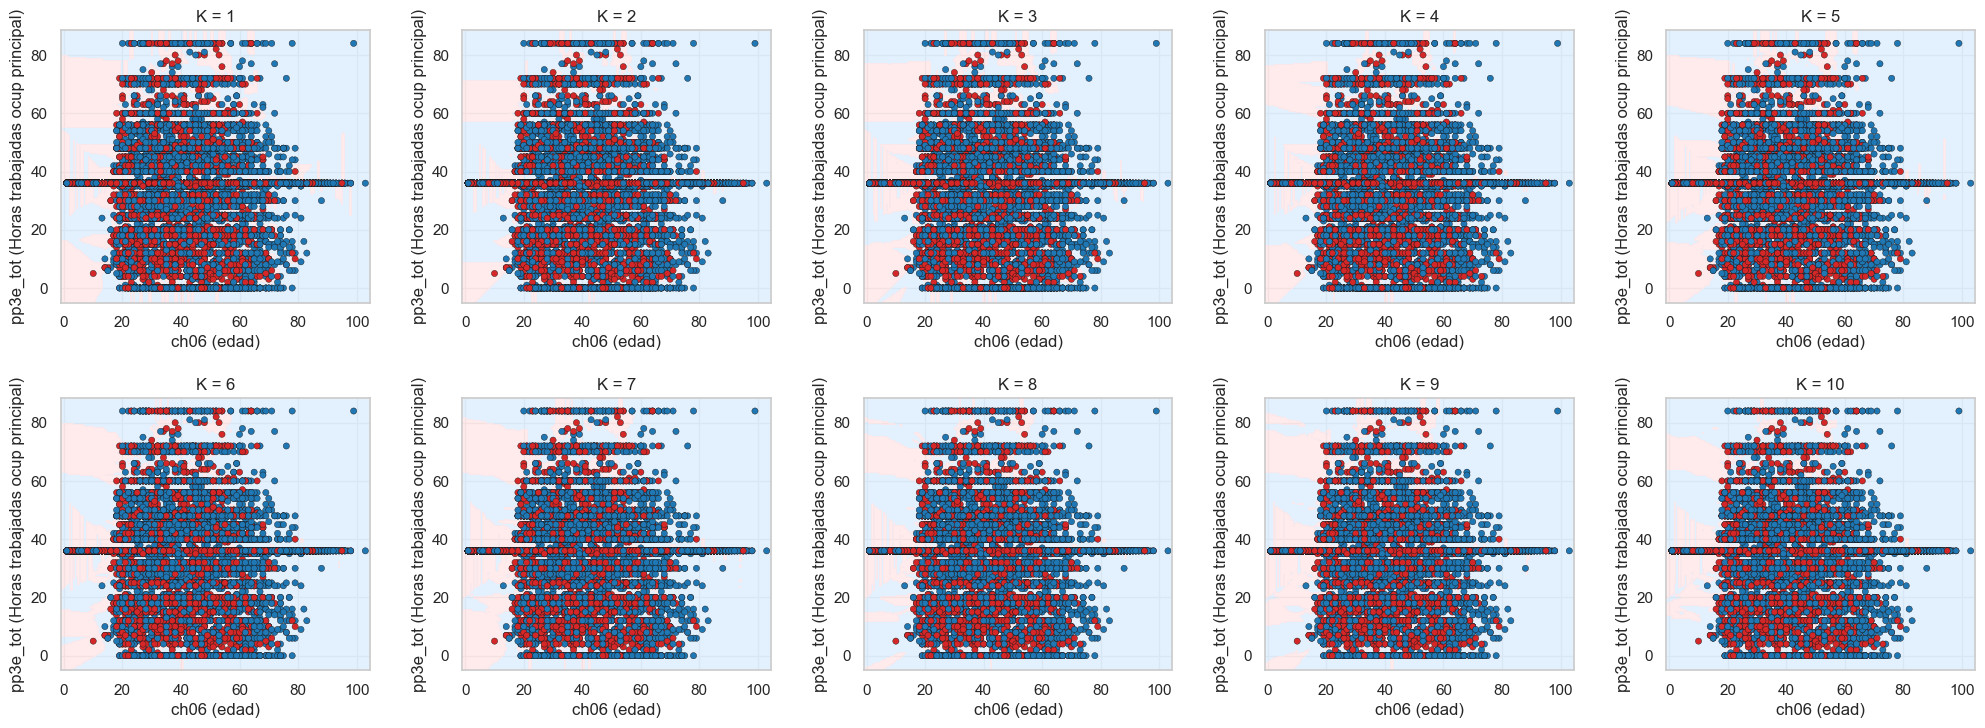

In [48]:
# ============================
# 3. Graficar para K = 1 a 10
# ============================
Ks = range(1, 11)

fig, axes = plt.subplots(2, 5, figsize=(22, 8))

# Márgenes más grandes
fig.subplots_adjust(
    left=0.08,   # margen izquierdo
    right=0.95,  # margen derecho
    top=0.90,    # margen superior
    bottom=0.10, # margen inferior
    wspace=0.30, # espacio horizontal entre subplots
    hspace=0.35  # espacio vertical
)

# Colores
cmap_bg = ListedColormap(["#ddeeff", "#ffe6e6"])
cmap_pts = ListedColormap(["#1f77b4", "#d62728"])

axes = axes.ravel()

for ax, K in zip(axes, Ks):

    knn = KNeighborsClassifier(n_neighbors=K)
    knn.fit(X_arr, y_arr)

    # Predicción sobre la malla
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Fondo y fronteras
    ax.contourf(xx, yy, Z,
                alpha=0.8, cmap=cmap_bg,
                levels=[-0.5, 0.5, 1.5])

    # Puntos reales (sin escalar)
    ax.scatter(X_arr[:, 0], X_arr[:, 1],
               c=y_arr, cmap=cmap_pts,
               s=20, edgecolor="k", linewidth=0.3)

    ax.set_title(f"K = {K}")
    ax.set_xlabel("ch06 (edad)")
    ax.set_ylabel("pp3e_tot (Horas trabajadas ocup principal)")


7.	K optimo por Cross-validation: Dividan la base X_train de respondieron_2025 en 5 partes (5-fold) para obtener el K óptimo por Cross-Validation con K=(1,10). Llamenle a este modelo KNN con K-CV. Grafiquen el accuracy de cada modelo y comenten cual es el número óptimo de vecinos cercanos para identificar pobres.

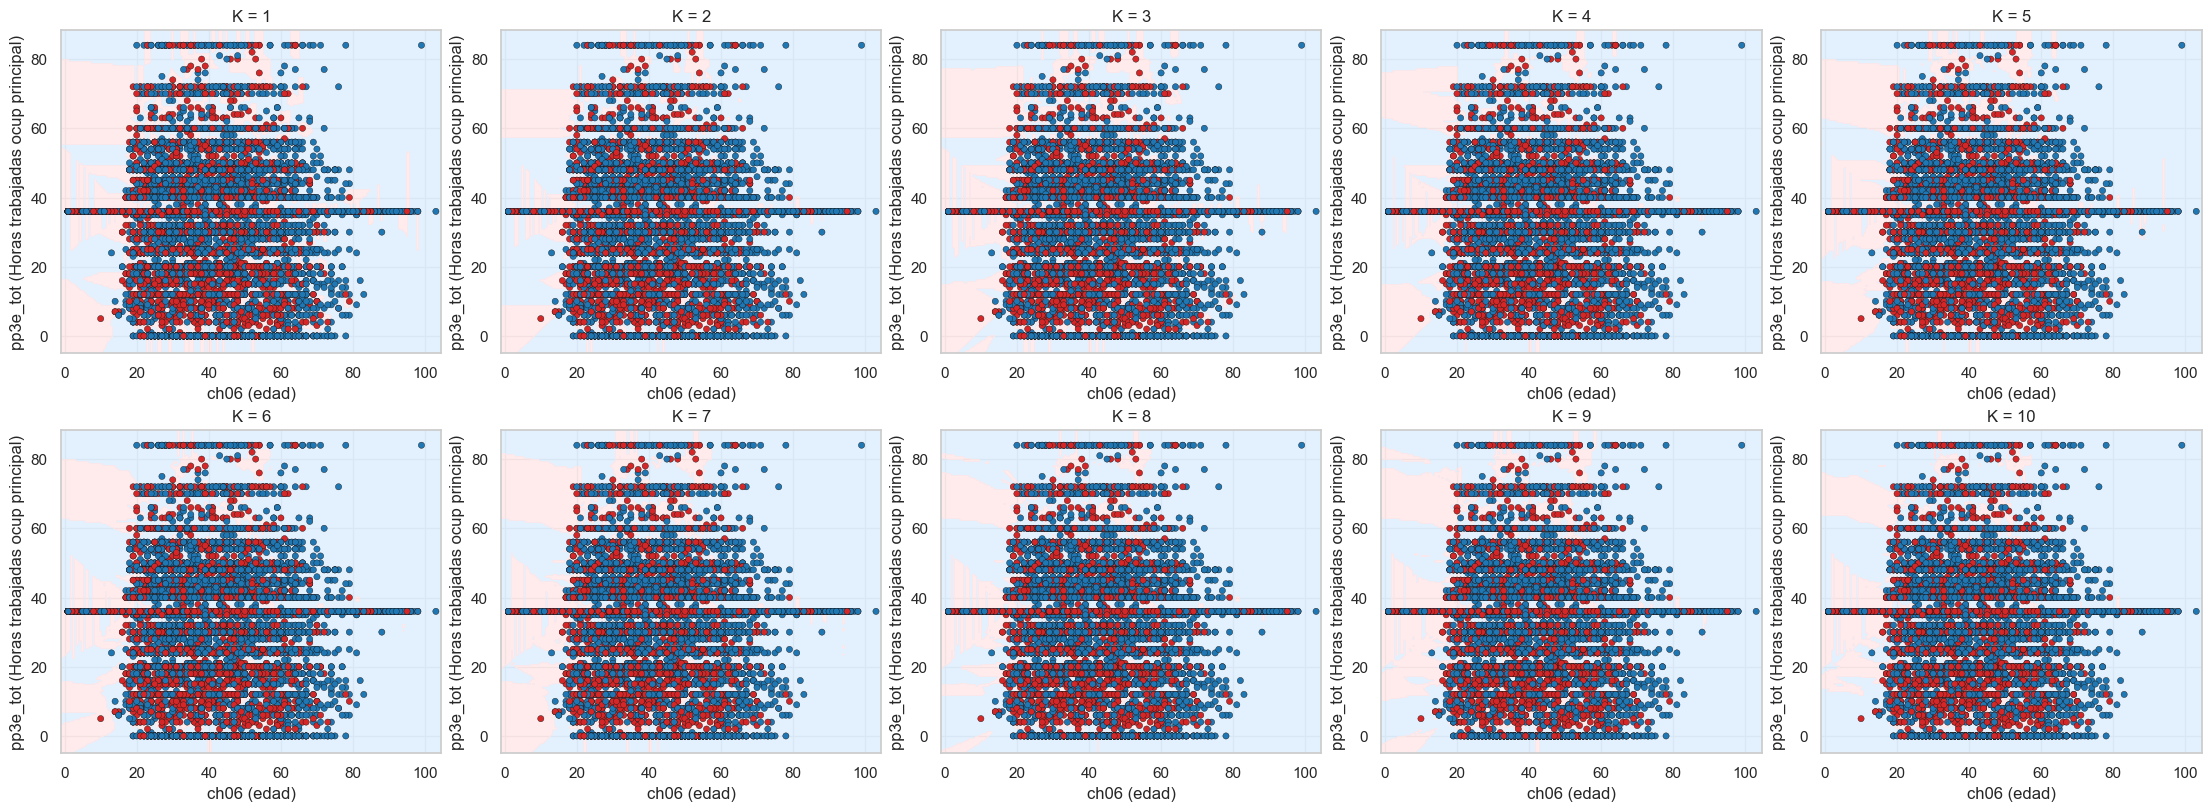

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.neighbors import KNeighborsClassifier

# ============================
# 1. Preparación de X e y
# ============================

# Quitar constante si está presente
X_knn = X_train_knn.drop(columns=["const"], errors="ignore")

# Variables numéricas a usar
X_arr = X_knn[["ch06", "pp3e_tot_clean"]].values

# Variable objetivo
y_arr = y_train_2025.values

# ============================
# 2. Crear malla para frontera
# ============================
h = 0.5  # Ajustado (sin escalar ch06 puede estar entre 0-100!)

x_min, x_max = X_arr[:, 0].min() - 2, X_arr[:, 0].max() + 2
y_min, y_max = X_arr[:, 1].min() - 5, X_arr[:, 1].max() + 5

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

# ============================
# 3. Graficar para K = 1 a 10
# ============================
Ks = range(1, 11)

fig, axes = plt.subplots(2, 5, figsize=(22, 8), constrained_layout=True)

# Colores
cmap_bg = ListedColormap(["#ddeeff", "#ffe6e6"])  # Fondos
cmap_pts = ListedColormap(["#1f77b4", "#d62728"]) # Puntos

axes = axes.ravel()

for ax, K in zip(axes, Ks):

    knn = KNeighborsClassifier(n_neighbors=K)
    knn.fit(X_arr, y_arr)

    # Predicción sobre la malla
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Fondo y frontera
    ax.contourf(xx, yy, Z,
                alpha=0.8, cmap=cmap_bg,
                levels=[-0.5, 0.5, 1.5])

    # Puntos reales (sin escalar)
    ax.scatter(X_arr[:, 0], X_arr[:, 1],
               c=y_arr, cmap=cmap_pts,
               s=20, edgecolor="k", linewidth=0.3)

    ax.set_title(f"K = {K}")
    ax.set_xlabel("ch06 (edad)")
    ax.set_ylabel("pp3e_tot (Horas trabajadas ocup principal)")

plt.show()


In [24]:

# 1. Definimos los valores de K a probar
k_values = range(1, 11)
cv_scores = []

# 2. Cross-validation con 5 pliegues
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_knn, y_train_2025, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())


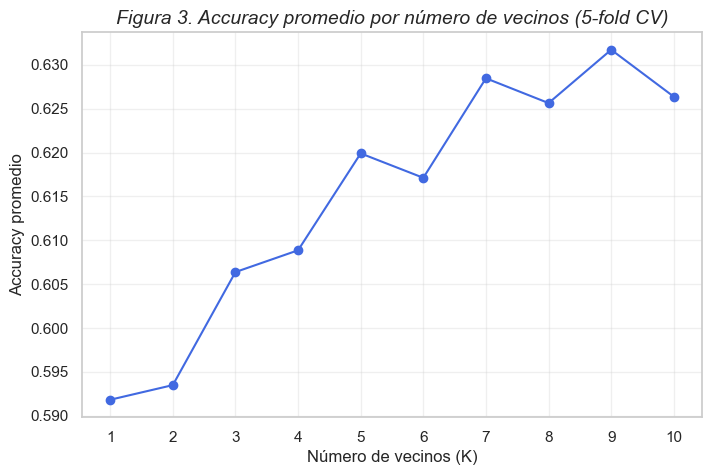

✅ K óptimo según 5-fold CV: 9 (accuracy promedio = 0.632)


In [50]:
#  Graficamos los resultados
plt.figure(figsize=(8,5))
plt.plot(k_values, cv_scores, marker='o', linestyle='-', color='royalblue')
plt.title('Figura 3. Accuracy promedio por número de vecinos (5-fold CV)', fontsize=14, style='italic', loc='center')
plt.xlabel('Número de vecinos (K)')
plt.ylabel('Accuracy promedio')
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.show()

# Mostramos el K óptimo
k_optimo = k_values[np.argmax(cv_scores)]
accuracy_max = max(cv_scores)
print(f"✅ K óptimo según 5-fold CV: {k_optimo} (accuracy promedio = {accuracy_max:.3f})")

## D. Desempeño de modelos afuera de la muestra, métricas y políticas públicas
### Ejercicio 8 – Comparación de Logit vs KNN en test 2025


In [51]:
from sklearn.neighbors import KNeighborsClassifier

# ---------------------------
# 1A. Probabilidades del Logit
# ---------------------------
# 'result' es el modelo logístico estimado con statsmodels
# X_test_2025 ya tiene la misma estructura que lo que usaste para entrenar (incluye 'const' si la agregaste)
proba_logit_test = result.predict(X_test_2025)   # devuelve P(pobre=1 | X)

# ---------------------------
# 1B. Probabilidades del KNN
# ---------------------------
# Entrenamos un KNN final con el K óptimo encontrado por CV
knn_final = KNeighborsClassifier(n_neighbors=k_optimo)
knn_final.fit(X_train_knn, y_train_2025)

# Probabilidades de ser pobre en el test (columna de la clase 1)
proba_knn_test = knn_final.predict_proba(X_test_knn)[:, 1]


In [52]:
from sklearn.metrics import confusion_matrix

# Elegimos el umbral
umbral = 0.5

# Clasificaciones 0/1 del Logit
y_hat_logit_05 = (proba_logit_test >= umbral).astype(int)

# Matriz de confusión
cm_logit = confusion_matrix(y_test_2025, y_hat_logit_05)

print("Matriz de confusión Logit (umbral 0.5):")
print(cm_logit)


Matriz de confusión Logit (umbral 0.5):
[[4063 1402]
 [2163 2384]]


### Ejercicio 9

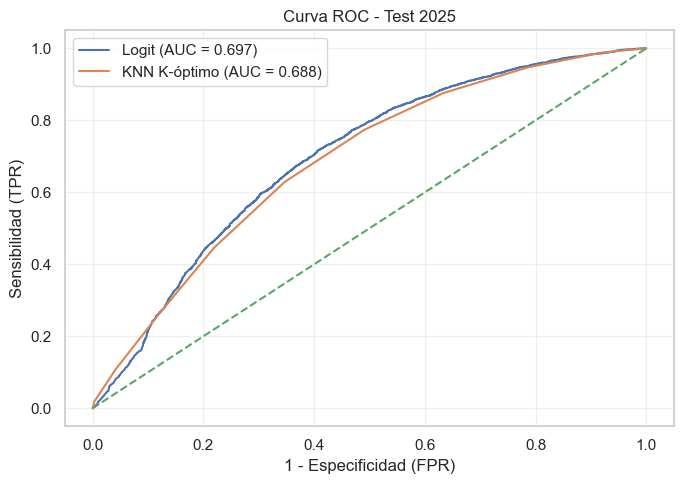

In [53]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Curvas ROC
fpr_logit, tpr_logit, _ = roc_curve(y_test_2025, proba_logit_test)
fpr_knn,   tpr_knn,   _ = roc_curve(y_test_2025, proba_knn_test)

# AUC de cada modelo
auc_logit = roc_auc_score(y_test_2025, proba_logit_test)
auc_knn   = roc_auc_score(y_test_2025, proba_knn_test)

# Gráfico
plt.figure(figsize=(7, 5))
plt.plot(fpr_logit, tpr_logit, label=f"Logit (AUC = {auc_logit:.3f})")
plt.plot(fpr_knn,   tpr_knn,   label=f"KNN K-óptimo (AUC = {auc_knn:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")  # Modelo azar

plt.xlabel("1 - Especificidad (FPR)")
plt.ylabel("Sensibilidad (TPR)")
plt.title("Curva ROC - Test 2025")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [54]:
from sklearn.metrics import accuracy_score, recall_score, precision_score
import pandas as pd

def metricas_clasificacion(y_true, proba, umbral=0.5):
    """
    Calcula métricas básicas de clasificación para un modelo dado un umbral.
    """
    y_hat = (proba >= umbral).astype(int)
    acc  = accuracy_score(y_true, y_hat)
    rec  = recall_score(y_true, y_hat)      # sensibilidad sobre pobres
    prec = precision_score(y_true, y_hat)
    
    return pd.Series({
        "Accuracy": acc,
        "Recall (Sensibilidad)": rec,
        "Precisión": prec
    })

tabla_metricas = pd.DataFrame({
    "Logit":   metricas_clasificacion(y_test_2025, proba_logit_test, umbral=0.5),
    "KNN_KCV": metricas_clasificacion(y_test_2025, proba_knn_test,   umbral=0.5)
})

print("Métricas en test 2025 (umbral 0.5):")
display(tabla_metricas)


Métricas en test 2025 (umbral 0.5):


,Logit,KNN_KCV
Accuracy,0.643927,0.642129
Recall (Sensibilidad),0.524302,0.628766
Precisión,0.629688,0.601388


#### Ejercicio 10

In [55]:
# Buscamos calcular el número de pobres predichos en la base no respondieron

norespondieron["pp3e_tot_clean"] = norespondieron["pp3e_tot"].where(norespondieron["pp3e_tot"] <= q99)


In [56]:
def preparar_X(df, referencia_cols=None):
    """
    
    Usaremos las mismas variables que el Logit/KNN.
    """
    vars_pred = ['ch04', 'ch06', 'ch07', 'pp3e_tot_clean',
                 'nivel_ed', 'estado', 'ch03', 'ch09', 'ch10']
    num_cols  = ['ch06', 'ch07', 'pp3e_tot_clean', 'estado', 'ch09', 'ch10']
    cat_cols  = ['ch04', 'nivel_ed']

    # DataFrame de trabajo
    df_modelo = df[vars_pred].copy()

    # Imputar NAs numéricas con la mediana
    for col in num_cols:
        med = df_modelo[col].median()
        df_modelo[col] = df_modelo[col].fillna(med)

    # Dummies para categóricas
    df_modelo = pd.get_dummies(df_modelo, columns=cat_cols, drop_first=True)

    # Alinear columnas con las de referencia (por ej. X_train_knn)
    if referencia_cols is not None:
        for c in referencia_cols:
            if c not in df_modelo.columns:
                df_modelo[c] = 0
        df_modelo = df_modelo[referencia_cols]

    return df_modelo


In [41]:
# Columnas que usa el KNN (las de X_train_knn)
cols_knn = X_train_knn.columns

# Preparar las X para norespondieron_2025
X_noresp_2025 = preparar_X(norespondieron_2025, referencia_cols=cols_knn)


In [42]:
# Probabilidades de ser pobre según el KNN final
proba_noresp = knn_final.predict_proba(X_noresp_2025)[:, 1]

umbral = 0.5
y_hat_noresp = (proba_noresp >= umbral).astype(int)

prop_pobres_noresp = y_hat_noresp.mean()
print(f"Proporción de pobres predichos en norespondieron_2025: {prop_pobres_noresp:.3%}")


Proporción de pobres predichos en norespondieron_2025: 73.185%
